<a href="https://colab.research.google.com/github/datacentertugaskuliah-coder/PraktekJST/blob/main/Bank_Marketing_ML_Pipeline_Streamlit_Deployment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bank Marketing Neural Network Research Pipeline and Streamlit Deployment

**Deskripsi singkat:** Notebook ini menyajikan tahapan penelitian Machine Learning/Data Mining/Data Science secara sistematis untuk dataset UCI Bank Marketing. Program mencakup EDA, preprocessing, pemodelan JST berbasis `MLPClassifier`, diagnosis imbalance/underfitting/overfitting, revisi logis, evaluasi model, pengujian 7 data baru dari hold-out test set, penyimpanan model dengan `joblib`, dan pembuatan aplikasi interaktif Streamlit melalui ngrok.

**Integritas penelitian:** Semua angka hasil seperti accuracy, precision, recall, F1-score, ROC-AUC, dan PR-AUC harus berasal dari output eksekusi notebook. Notebook ini tidak membuat angka hasil secara asumtif. Data test tidak digunakan untuk training, tuning, atau resampling.

**Catatan keamanan token:** Token ngrok tidak ditulis langsung ke notebook agar tidak bocor saat file dibagikan. Saat menjalankan deployment, masukkan token melalui input tersembunyi, environment variable `NGROK_AUTH_TOKEN`, atau Colab Secrets.

## Step 1 — Environment Setup and Reproducibility Configuration

Tahap ini menyiapkan library, seed, dan folder artefak. Seed digunakan agar split data dan training lebih konsisten. Namun, hasil neural network tetap dapat memiliki variasi kecil pada runtime berbeda.

In [1]:
# ============================================================
# Output Title: Environment Setup and Reproducibility Configuration
# Deskripsi: Tahap ini memasang library dan mengatur seed agar eksperimen lebih reprodusibel.
# ============================================================

import sys
!{sys.executable} -m pip install -q ucimlrepo imbalanced-learn scikit-learn streamlit pyngrok joblib matplotlib pandas numpy

import os
import json
import random
import warnings
import subprocess
import time
import getpass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
USE_DURATION = False
SAVE_FIGURES = True

ARTIFACT_DIR = Path("artifacts")
MODEL_DIR = ARTIFACT_DIR / "models"
TABLE_DIR = ARTIFACT_DIR / "tables"
DATA_DIR = ARTIFACT_DIR / "data"
FIG_DIR = Path("figures")

for directory in [ARTIFACT_DIR, MODEL_DIR, TABLE_DIR, DATA_DIR, FIG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

import sklearn
from sklearn import set_config
set_config(transform_output="default")

def section(title):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)

def save_or_show(fig, filename):
    if SAVE_FIGURES:
        path = FIG_DIR / filename
        fig.savefig(path, dpi=300, bbox_inches="tight")
        print(f"Figure saved: {path}")
    plt.show()

section("Environment Setup and Reproducibility Configuration")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 52.8 MB/s eta 0:00:00

Environment Setup and Reproducibility Configuration
NumPy: 2.0.2
Pandas: 2.2.2
Scikit-learn: 1.6.1


## Step 2 — Data Acquisition and Research Objective

Tahap ini mengambil dataset langsung dari UCI Machine Learning Repository. Target penelitian adalah memprediksi apakah nasabah akan berlangganan deposito berjangka (`yes/no`).

In [2]:
# ============================================================
# Output Title: Data Acquisition and Research Objective
# Deskripsi: Data diambil dari UCI agar sumber data jelas dan dapat direplikasi.
# ============================================================

from ucimlrepo import fetch_ucirepo

section("Data Acquisition and Research Objective")

bank_marketing = fetch_ucirepo(id=222)
X_raw = bank_marketing.data.features.copy()
y_raw = bank_marketing.data.targets.copy()

if isinstance(y_raw, pd.DataFrame):
    y_series = y_raw.iloc[:, 0].copy()
else:
    y_series = pd.Series(y_raw).copy()

y = y_series.map({"no": 0, "yes": 1}).astype(int)

print("Research objective:")
print("Predict whether a bank client subscribes to a term deposit using a reproducible neural network pipeline.")
print("\nRaw feature matrix shape:", X_raw.shape)
print("Target vector shape:", y.shape)

display(X_raw.head())

target_definition = pd.DataFrame({
    "original_label": ["no", "yes"],
    "encoded_label": [0, 1],
    "meaning": ["Client did not subscribe to term deposit", "Client subscribed to term deposit"]
})
display(target_definition)

target_summary = pd.DataFrame({
    "target": ["No", "Yes"],
    "count": y.value_counts().sort_index().values,
    "proportion": y.value_counts(normalize=True).sort_index().values
})
display(target_summary)


Data Acquisition and Research Objective
Research objective:
Predict whether a bank client subscribes to a term deposit using a reproducible neural network pipeline.

Raw feature matrix shape: (45211, 16)
Target vector shape: (45211,)


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN


,original_label,encoded_label,meaning
0,no,0,Client did not subscribe to term deposit
1,yes,1,Client subscribed to term deposit


,target,count,proportion
0,No,39922,0.883015
1,Yes,5289,0.116985


## Step 3 — Data Audit, EDA, and Leakage Control

Tahap EDA memeriksa struktur data, missing value, tipe fitur, distribusi target, dan potensi leakage. Variabel `duration` dikeluarkan secara default karena durasi panggilan baru diketahui setelah panggilan selesai.


Data Audit, EDA, and Leakage Control


,feature,dtype,missing_count,missing_percent,unique_values
0,age,int64,0,0.0000,77
1,job,object,288,0.6370,11
2,marital,object,0,0.0000,3
3,education,object,1857,4.1074,3
4,default,object,0,0.0000,2
5,balance,int64,0,0.0000,7168
6,housing,object,0,0.0000,2
7,loan,object,0,0.0000,2
8,contact,object,13020,28.7983,2
9,day_of_week,int64,0,0.0000,31


Leakage control: the feature 'duration' is removed for realistic pre-call prediction.


,feature_type,number_of_features,features
0,Numeric,6,"age, balance, day_of_week, campaign, pdays, pr..."
1,Categorical,9,"job, marital, education, default, housing, loa..."


Figure saved: figures/figure_01_target_distribution.png


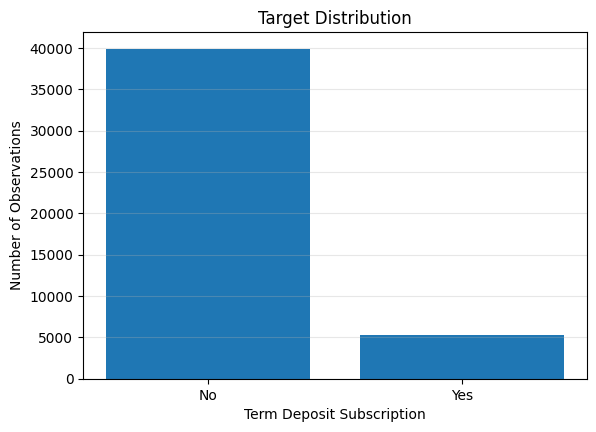

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day_of_week,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


Figure saved: figures/figure_eda_numeric_age.png


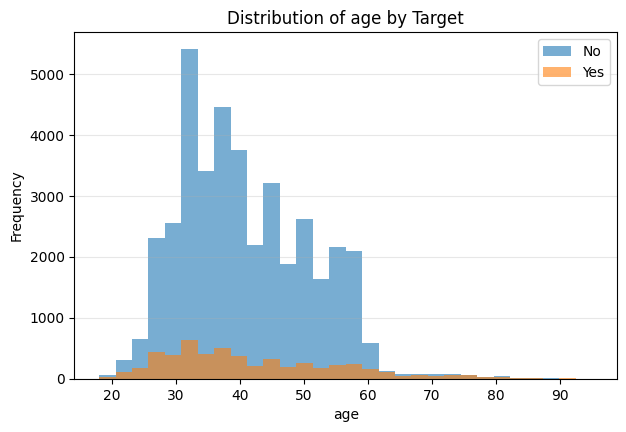

Figure saved: figures/figure_eda_numeric_balance.png


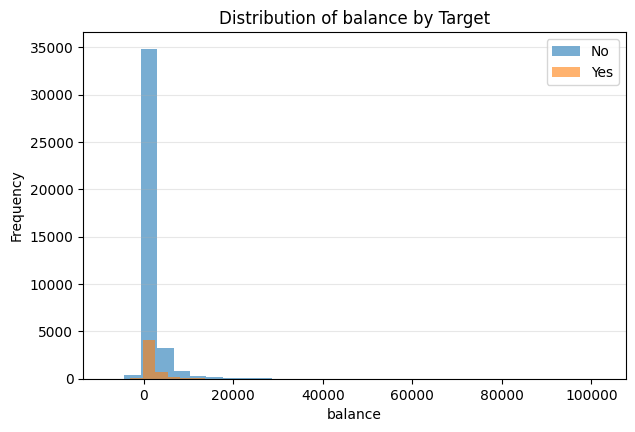

Figure saved: figures/figure_eda_numeric_day_of_week.png


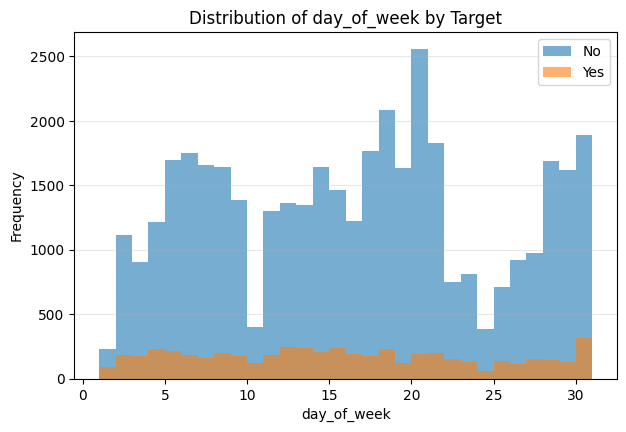

Figure saved: figures/figure_eda_numeric_campaign.png


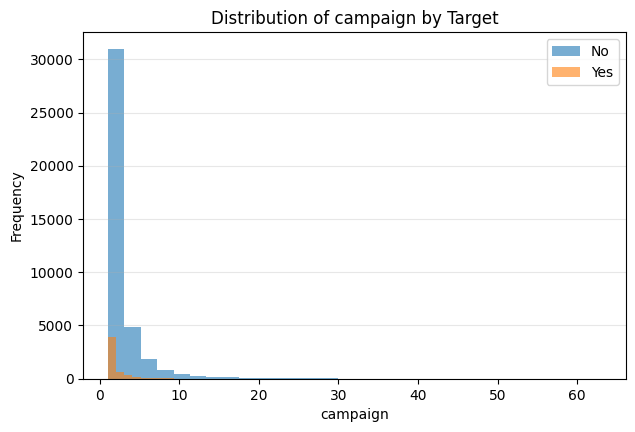

Figure saved: figures/figure_eda_numeric_pdays.png


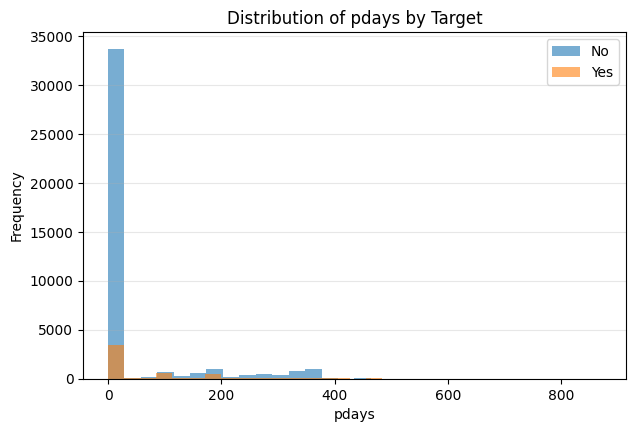

Figure saved: figures/figure_eda_numeric_previous.png


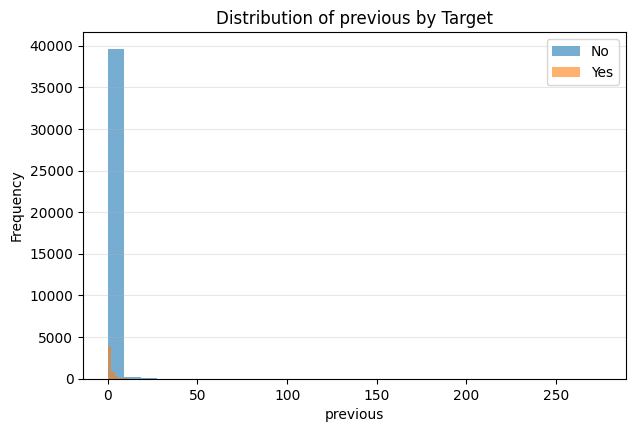


Positive rate by job


,No,Yes
job,,
student,0.713220,0.286780
retired,0.772085,0.227915
unemployed,0.844973,0.155027
management,0.862444,0.137556
admin.,0.877973,0.122027
self-employed,0.881571,0.118429
technician,0.889430,0.110570
services,0.911170,0.088830
housemaid,0.912097,0.087903


Figure saved: figures/figure_eda_categorical_job.png


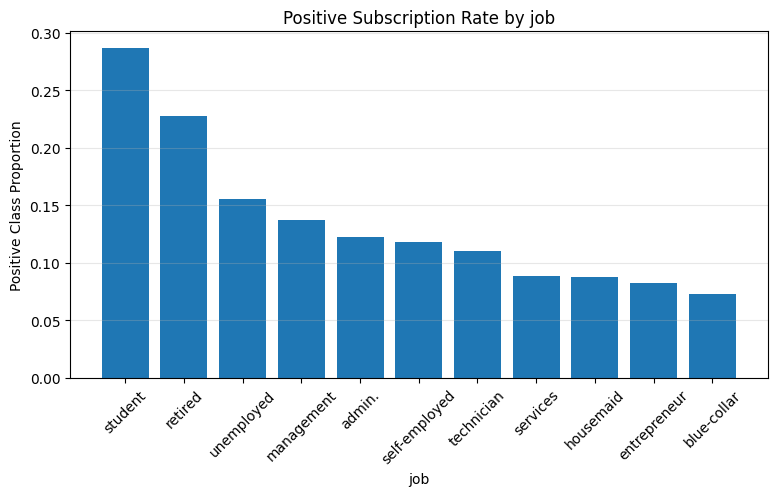


Positive rate by marital


,No,Yes
marital,,
single,0.850508,0.149492
divorced,0.880545,0.119455
married,0.898765,0.101235


Figure saved: figures/figure_eda_categorical_marital.png


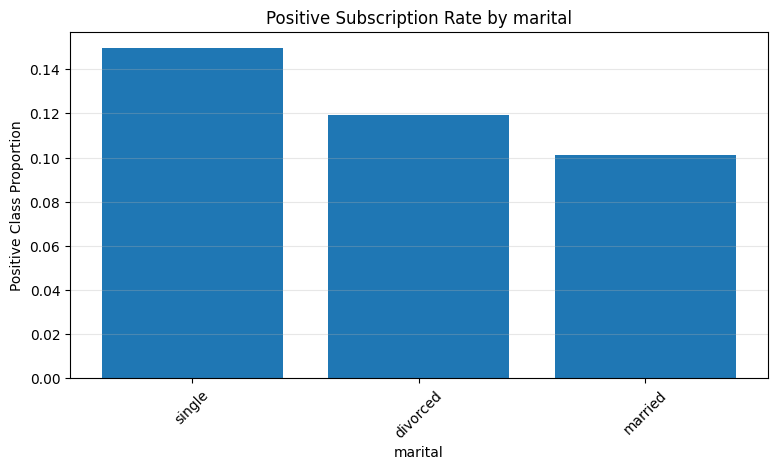


Positive rate by education


,No,Yes
education,,
tertiary,0.849936,0.150064
secondary,0.894406,0.105594
primary,0.913735,0.086265


Figure saved: figures/figure_eda_categorical_education.png


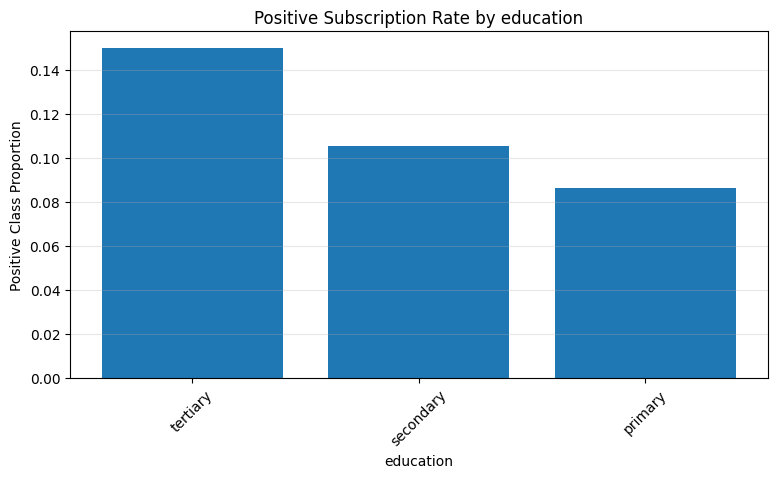


Positive rate by default


,No,Yes
default,,
no,0.882039,0.117961
yes,0.936196,0.063804


Figure saved: figures/figure_eda_categorical_default.png


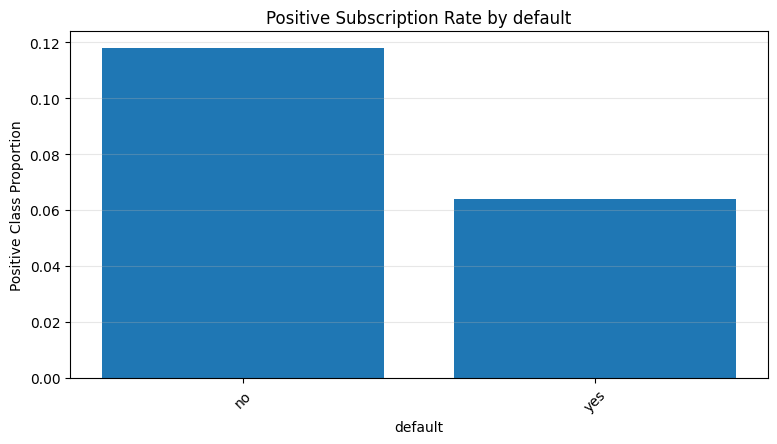


Positive rate by housing


,No,Yes
housing,,
no,0.832976,0.167024
yes,0.923000,0.077000


Figure saved: figures/figure_eda_categorical_housing.png


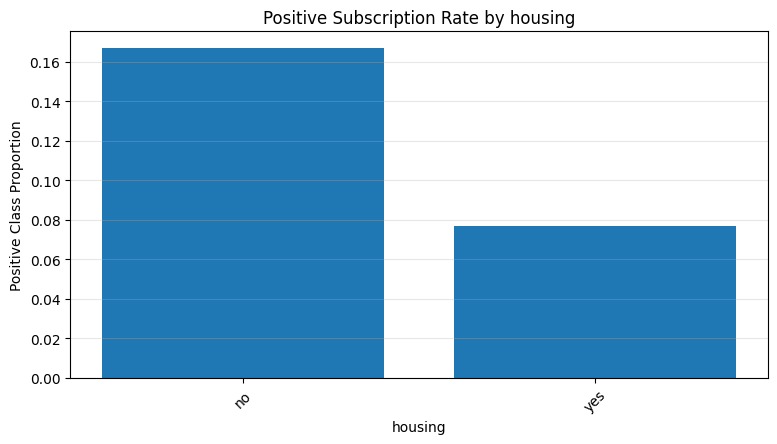


Positive rate by loan


,No,Yes
loan,,
no,0.873443,0.126557
yes,0.933186,0.066814


Figure saved: figures/figure_eda_categorical_loan.png


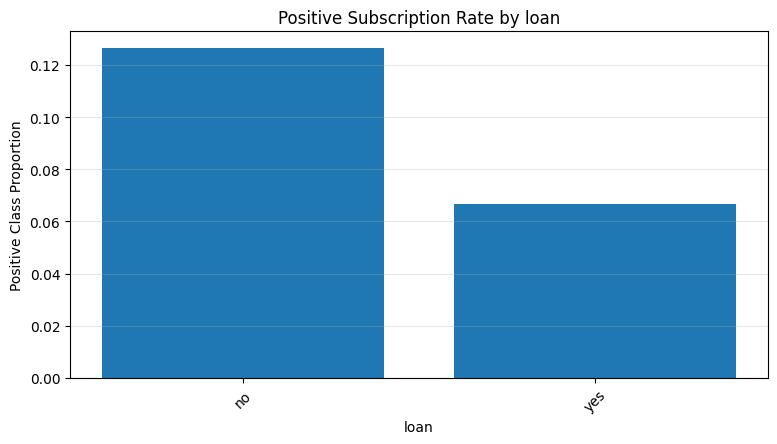

In [3]:
# ============================================================
# Output Title: Data Audit, EDA, and Leakage Control
# Deskripsi: Tahap ini memastikan data dipahami sebelum model dibangun.
# ============================================================

section("Data Audit, EDA, and Leakage Control")

X = X_raw.copy()

audit_table = pd.DataFrame({
    "feature": X.columns,
    "dtype": X.dtypes.astype(str).values,
    "missing_count": X.isna().sum().values,
    "missing_percent": (X.isna().mean().values * 100).round(4),
    "unique_values": [X[col].nunique(dropna=True) for col in X.columns]
})
display(audit_table)

if not USE_DURATION and "duration" in X.columns:
    X = X.drop(columns=["duration"])
    print("Leakage control: the feature 'duration' is removed for realistic pre-call prediction.")
else:
    print("Leakage warning: 'duration' is retained; interpret results as post-call benchmark only.")

numeric_features_all = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_features_all = X.select_dtypes(exclude=["int64", "float64", "int32", "float32"]).columns.tolist()

feature_type_summary = pd.DataFrame({
    "feature_type": ["Numeric", "Categorical"],
    "number_of_features": [len(numeric_features_all), len(categorical_features_all)],
    "features": [", ".join(numeric_features_all), ", ".join(categorical_features_all)]
})
display(feature_type_summary)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.bar(target_summary["target"], target_summary["count"])
ax.set_title("Target Distribution")
ax.set_xlabel("Term Deposit Subscription")
ax.set_ylabel("Number of Observations")
ax.grid(axis="y", alpha=0.3)
save_or_show(fig, "figure_01_target_distribution.png")

if numeric_features_all:
    numeric_summary = X[numeric_features_all].describe().T
    display(numeric_summary)

    for col in numeric_features_all[:6]:
        fig, ax = plt.subplots(figsize=(7.0, 4.5))
        ax.hist(X.loc[y == 0, col].dropna(), bins=30, alpha=0.60, label="No")
        ax.hist(X.loc[y == 1, col].dropna(), bins=30, alpha=0.60, label="Yes")
        ax.set_title(f"Distribution of {col} by Target")
        ax.set_xlabel(col)
        ax.set_ylabel("Frequency")
        ax.legend()
        ax.grid(axis="y", alpha=0.3)
        save_or_show(fig, f"figure_eda_numeric_{col}.png")

for col in categorical_features_all[:6]:
    ctab = pd.crosstab(X[col], y, normalize="index")
    if 0 not in ctab.columns:
        ctab[0] = 0
    if 1 not in ctab.columns:
        ctab[1] = 0
    ctab = ctab[[0, 1]]
    ctab.columns = ["No", "Yes"]
    ctab = ctab.sort_values("Yes", ascending=False)

    print(f"\nPositive rate by {col}")
    display(ctab.head(15))

    fig, ax = plt.subplots(figsize=(9.0, 4.5))
    plot_data = ctab.head(15)
    ax.bar(plot_data.index.astype(str), plot_data["Yes"])
    ax.set_title(f"Positive Subscription Rate by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Positive Class Proportion")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.3)
    save_or_show(fig, f"figure_eda_categorical_{col}.png")

## Step 4 — Stratified Split and Preprocessing Pipeline

Data dibagi menjadi train, validation, dan test secara stratified. Preprocessing hanya di-fit pada train set agar tidak terjadi information leakage.


Stratified Split and Preprocessing Pipeline


,split,n_rows,positive_rate,negative_rate
0,Training,28934,0.116990,0.883010
1,Validation,7234,0.116948,0.883052
2,Test,9043,0.116997,0.883003


Figure saved: figures/figure_02_positive_rate_split.png


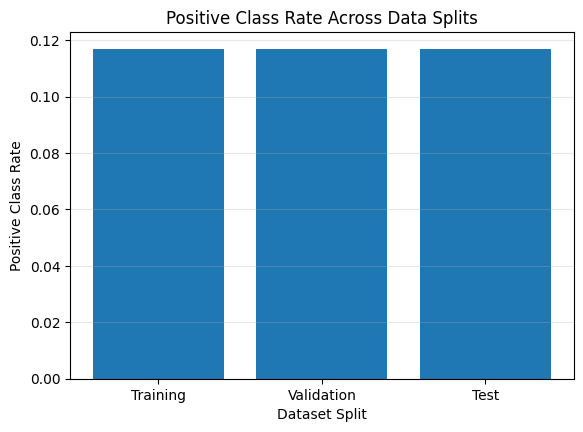

,split,rows,processed_features
0,Training,28934,46
1,Validation,7234,46
2,Test,9043,46


In [4]:
# ============================================================
# Output Title: Stratified Split and Preprocessing Pipeline
# Deskripsi: Split dan preprocessing dilakukan secara konsisten untuk menjaga validitas evaluasi.
# ============================================================

section("Stratified Split and Preprocessing Pipeline")

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=RANDOM_STATE
)

split_summary = pd.DataFrame({
    "split": ["Training", "Validation", "Test"],
    "n_rows": [len(y_train), len(y_val), len(y_test)],
    "positive_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
    "negative_rate": [1 - y_train.mean(), 1 - y_val.mean(), 1 - y_test.mean()]
})
display(split_summary)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.bar(split_summary["split"], split_summary["positive_rate"])
ax.set_title("Positive Class Rate Across Data Splits")
ax.set_xlabel("Dataset Split")
ax.set_ylabel("Positive Class Rate")
ax.grid(axis="y", alpha=0.3)
save_or_show(fig, "figure_02_positive_rate_split.png")

numeric_features = X_train.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["int64", "float64", "int32", "float32"]).columns.tolist()

try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot)
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ],
    remainder="drop"
)

X_train_p = preprocess.fit_transform(X_train)
X_val_p = preprocess.transform(X_val)
X_test_p = preprocess.transform(X_test)

processed_summary = pd.DataFrame({
    "split": ["Training", "Validation", "Test"],
    "rows": [X_train_p.shape[0], X_val_p.shape[0], X_test_p.shape[0]],
    "processed_features": [X_train_p.shape[1], X_val_p.shape[1], X_test_p.shape[1]]
})
display(processed_summary)

## Step 5 — Evaluation Functions and Error-Diagnostic Logic

Fungsi evaluasi dibuat seragam agar model baseline dan model revisi dapat dibandingkan secara adil. Metrik utama adalah PR-AUC karena target positif relatif minoritas.

In [5]:
# ============================================================
# Output Title: Evaluation Functions and Error-Diagnostic Logic
# Deskripsi: Fungsi evaluasi dan diagnosis dibuat eksplisit agar hasil dapat diaudit.
# ============================================================

section("Evaluation Functions and Error-Diagnostic Logic")

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, precision_recall_curve, roc_curve, brier_score_loss
)
from sklearn.calibration import calibration_curve

def best_threshold_by_f1(y_true, y_proba):
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
    best_idx = int(np.argmax(f1_scores))
    return float(thresholds[best_idx]), float(f1_scores[best_idx])

def evaluate_binary_model(model_name, y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "model": model_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        "brier_score": brier_score_loss(y_true, y_proba)
    }

def print_model_report(model_name, y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    section(f"{model_name}: Classification Report")
    print(f"Decision threshold: {threshold:.4f}")
    print(classification_report(y_true, y_pred, zero_division=0))
    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))

def plot_confusion_matrix(y_true, y_proba, threshold, title, filename):
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    im = ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("Actual Class")
    ax.set_xticks([0, 1], labels=["No", "Yes"])
    ax.set_yticks([0, 1], labels=["No", "Yes"])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    fig.colorbar(im, ax=ax)
    save_or_show(fig, filename)

def plot_learning_curve(history, title, filename):
    fig, ax = plt.subplots(figsize=(7.0, 4.5))
    ax.plot(history["train_loss"], label="Training Loss")
    ax.plot(history["validation_loss"], label="Validation Loss")
    ax.set_title(title)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(alpha=0.3)
    save_or_show(fig, filename)

def plot_roc_pr_curves(model_probas, y_true, prefix):
    fig, ax = plt.subplots(figsize=(7.0, 5.0))
    for name, proba in model_probas.items():
        fpr, tpr, _ = roc_curve(y_true, proba)
        ax.plot(fpr, tpr, label=f"{name} | ROC-AUC={roc_auc_score(y_true, proba):.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
    ax.set_title("Receiver Operating Characteristic Curve")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()
    ax.grid(alpha=0.3)
    save_or_show(fig, f"{prefix}_roc_curve.png")

    fig, ax = plt.subplots(figsize=(7.0, 5.0))
    for name, proba in model_probas.items():
        precision, recall, _ = precision_recall_curve(y_true, proba)
        ax.plot(recall, precision, label=f"{name} | PR-AUC={average_precision_score(y_true, proba):.3f}")
    ax.set_title("Precision-Recall Curve")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend()
    ax.grid(alpha=0.3)
    save_or_show(fig, f"{prefix}_precision_recall_curve.png")

def plot_calibration_curve(model_probas, y_true, filename):
    fig, ax = plt.subplots(figsize=(6.0, 5.0))
    ax.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
    for name, proba in model_probas.items():
        frac_pos, mean_pred = calibration_curve(y_true, proba, n_bins=10, strategy="quantile")
        ax.plot(mean_pred, frac_pos, marker="o", label=name)
    ax.set_title("Calibration Curve")
    ax.set_xlabel("Mean Predicted Probability")
    ax.set_ylabel("Observed Positive Fraction")
    ax.legend()
    ax.grid(alpha=0.3)
    save_or_show(fig, filename)

print("Evaluation functions are ready.")


Evaluation Functions and Error-Diagnostic Logic
Evaluation functions are ready.


## Step 6 — Baseline Neural Network Model

Model baseline menggunakan `MLPClassifier` sebagai implementasi JST tabular. Baseline diperlukan agar setiap revisi dapat dibandingkan dengan titik awal yang jelas.


Baseline Neural Network Model

Baseline MLP Neural Network: Classification Report
Decision threshold: 0.2889
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      7985
           1       0.49      0.44      0.46      1058

    accuracy                           0.88      9043
   macro avg       0.71      0.69      0.70      9043
weighted avg       0.88      0.88      0.88      9043

Confusion matrix:
[[7506  479]
 [ 594  464]]
Figure saved: figures/figure_03_baseline_confusion_matrix.png


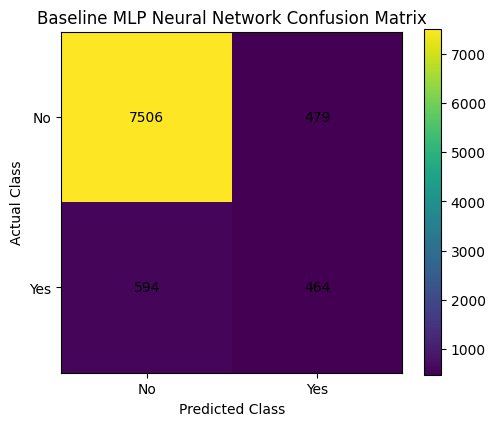

Figure saved: figures/figure_04_baseline_training_loss.png


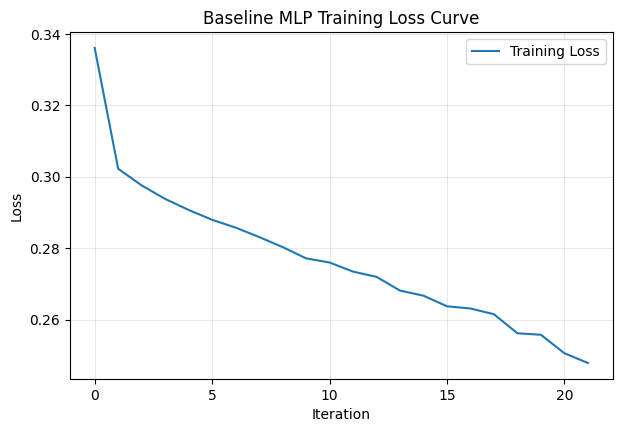

In [6]:
# ============================================================
# Output Title: Baseline Neural Network Model
# Deskripsi: Model baseline digunakan sebagai pembanding awal sebelum revisi otomatis.
# ============================================================

section("Baseline Neural Network Model")

from sklearn.neural_network import MLPClassifier

baseline_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size=256,
    learning_rate_init=1e-3,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=15,
    random_state=RANDOM_STATE
)

baseline_model.fit(X_train_p, y_train)

baseline_val_proba = baseline_model.predict_proba(X_val_p)[:, 1]
baseline_threshold, baseline_val_f1 = best_threshold_by_f1(y_val, baseline_val_proba)
baseline_test_proba = baseline_model.predict_proba(X_test_p)[:, 1]

baseline_result = evaluate_binary_model(
    "Baseline MLP Neural Network",
    y_test,
    baseline_test_proba,
    baseline_threshold
)

print_model_report(
    "Baseline MLP Neural Network",
    y_test,
    baseline_test_proba,
    baseline_threshold
)

plot_confusion_matrix(
    y_test,
    baseline_test_proba,
    baseline_threshold,
    "Baseline MLP Neural Network Confusion Matrix",
    "figure_03_baseline_confusion_matrix.png"
)

baseline_history = {
    "train_loss": baseline_model.loss_curve_,
    "validation_loss": baseline_model.validation_scores_ if hasattr(baseline_model, "validation_scores_") else []
}

fig, ax = plt.subplots(figsize=(7.0, 4.5))
ax.plot(baseline_model.loss_curve_, label="Training Loss")
ax.set_title("Baseline MLP Training Loss Curve")
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(alpha=0.3)
save_or_show(fig, "figure_04_baseline_training_loss.png")

## Step 7 — Automatic Diagnosis and Logical Revision

Tahap ini mendiagnosis imbalance, underfitting, overfitting, dan threshold risk. Revisi dilakukan berdasarkan bukti dari train-validation, bukan asumsi.

In [7]:
# ============================================================
# Output Title: Automatic Diagnosis and Logical Revision
# Deskripsi: Diagnosis digunakan untuk menentukan strategi revisi model secara logis.
# ============================================================

section("Automatic Diagnosis and Logical Revision")

train_proba_baseline = baseline_model.predict_proba(X_train_p)[:, 1]
train_pr_auc = average_precision_score(y_train, train_proba_baseline)
val_pr_auc = average_precision_score(y_val, baseline_val_proba)

minority_ratio = float(y_train.value_counts(normalize=True).min())
gap_pr_auc = float(train_pr_auc - val_pr_auc)

diagnosis_df = pd.DataFrame([{
    "minority_ratio_train": minority_ratio,
    "baseline_train_pr_auc": train_pr_auc,
    "baseline_validation_pr_auc": val_pr_auc,
    "train_validation_gap_pr_auc": gap_pr_auc,
    "baseline_best_validation_threshold": baseline_threshold
}])
display(diagnosis_df)

recommendations = []

if minority_ratio < 0.30:
    recommendations.append({
        "issue": "Class Imbalance",
        "evidence": f"Minority class ratio in training set = {minority_ratio:.4f}.",
        "revision": "Use train-only oversampling. Validation and test data must not be resampled."
    })

if gap_pr_auc > 0.05:
    recommendations.append({
        "issue": "Overfitting",
        "evidence": f"Train-validation PR-AUC gap = {gap_pr_auc:.4f}.",
        "revision": "Increase regularization, reduce model complexity, and use early stopping."
    })

if train_pr_auc < 0.45 and val_pr_auc < 0.45 and abs(gap_pr_auc) <= 0.05:
    recommendations.append({
        "issue": "Underfitting",
        "evidence": f"Train PR-AUC = {train_pr_auc:.4f}; validation PR-AUC = {val_pr_auc:.4f}.",
        "revision": "Increase capacity moderately and tune learning rate."
    })

if abs(baseline_threshold - 0.50) > 0.05:
    recommendations.append({
        "issue": "Default Threshold Risk",
        "evidence": f"Best validation F1 threshold = {baseline_threshold:.4f}.",
        "revision": "Use validation-based threshold instead of fixed 0.50."
    })

default_recommendations = [
    {
        "issue": "Metric Selection Risk",
        "evidence": "Accuracy can be misleading under class imbalance.",
        "revision": "Prioritize PR-AUC, F1-score, recall, precision, and balanced accuracy."
    },
    {
        "issue": "Calibration Risk",
        "evidence": "High discrimination does not guarantee calibrated probability.",
        "revision": "Report Brier score and calibration curve."
    },
    {
        "issue": "Reproducibility Risk",
        "evidence": "Results may change if seed, split, or library versions are not recorded.",
        "revision": "Save model, preprocessing pipeline, configuration, figures, and package versions."
    }
]

for item in default_recommendations:
    if len(recommendations) >= 3:
        break
    recommendations.append(item)

recommendations_df = pd.DataFrame(recommendations[:5])
display(recommendations_df)


Automatic Diagnosis and Logical Revision


,minority_ratio_train,baseline_train_pr_auc,baseline_validation_pr_auc,train_validation_gap_pr_auc,baseline_best_validation_threshold
0,0.11699,0.455312,0.426617,0.028695,0.288935


,issue,evidence,revision
0,Class Imbalance,Minority class ratio in training set = 0.1170.,Use train-only oversampling. Validation and te...
1,Default Threshold Risk,Best validation F1 threshold = 0.2889.,Use validation-based threshold instead of fixe...
2,Metric Selection Risk,Accuracy can be misleading under class imbalance.,"Prioritize PR-AUC, F1-score, recall, precision..."


## Step 8 — Revised Model Training with Train-Only Oversampling

Revisi model menerapkan oversampling hanya pada train set. Ini mencegah data leakage karena validation dan test tetap merepresentasikan distribusi asli.


Revised Model Training with Train-Only Oversampling


,stage,count
0,Before Resampling - No,25549
1,Before Resampling - Yes,3385
2,After Resampling - No,25549
3,After Resampling - Yes,25549


Figure saved: figures/figure_05_resampling_distribution.png


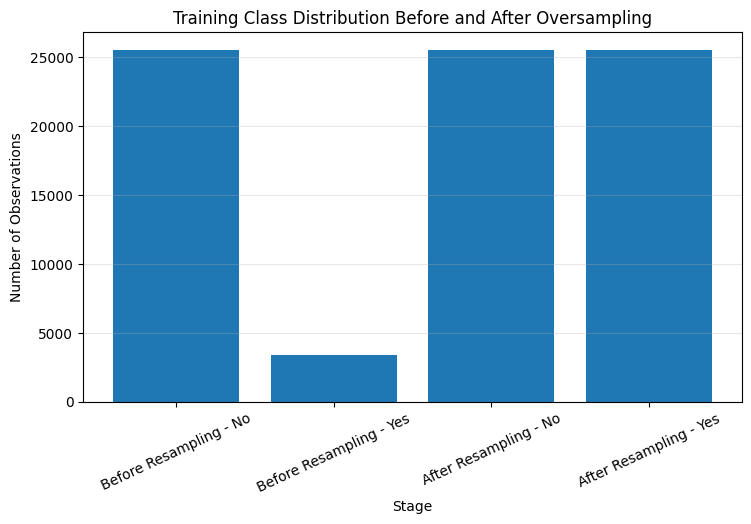

,revision_strategy,hidden_layers,alpha_l2_regularization,learning_rate_init,oversampling
0,Balanced Generalization Revision,"(128, 64, 32)",0.0005,0.0007,RandomOverSampler on training data only



Auto-Revised MLP Neural Network: Classification Report
Decision threshold: 0.6070
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      7985
           1       0.31      0.38      0.34      1058

    accuracy                           0.83      9043
   macro avg       0.61      0.63      0.62      9043
weighted avg       0.84      0.83      0.84      9043

Confusion matrix:
[[7090  895]
 [ 661  397]]
Figure saved: figures/figure_06_revised_confusion_matrix.png


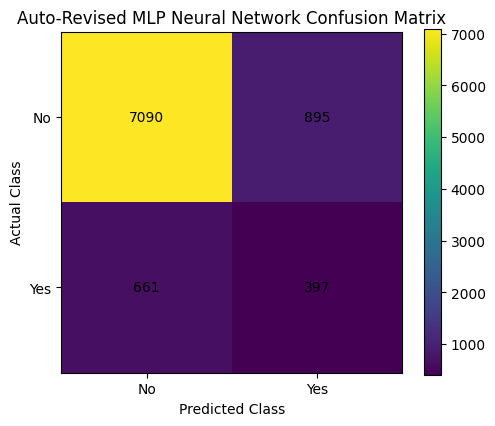

Figure saved: figures/figure_07_revised_training_loss.png


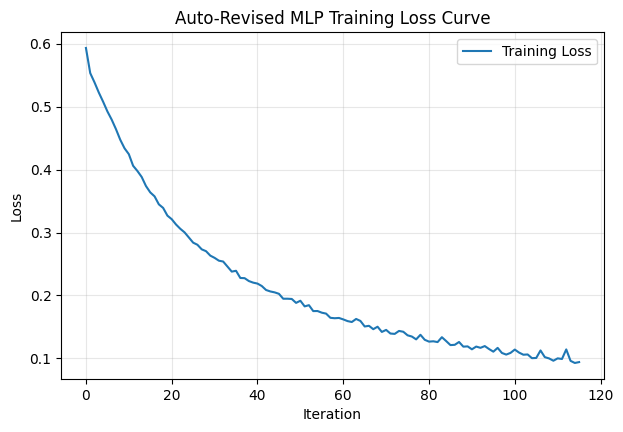

In [8]:
# ============================================================
# Output Title: Revised Model Training with Train-Only Oversampling
# Deskripsi: Revisi model dilakukan dengan oversampling hanya pada data train.
# ============================================================

section("Revised Model Training with Train-Only Oversampling")

from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = ros.fit_resample(X_train_p, y_train)

resampling_summary = pd.DataFrame({
    "stage": ["Before Resampling - No", "Before Resampling - Yes", "After Resampling - No", "After Resampling - Yes"],
    "count": [
        int((y_train == 0).sum()),
        int((y_train == 1).sum()),
        int((pd.Series(y_train_bal) == 0).sum()),
        int((pd.Series(y_train_bal) == 1).sum())
    ]
})
display(resampling_summary)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.bar(resampling_summary["stage"], resampling_summary["count"])
ax.set_title("Training Class Distribution Before and After Oversampling")
ax.set_xlabel("Stage")
ax.set_ylabel("Number of Observations")
ax.tick_params(axis="x", rotation=25)
ax.grid(axis="y", alpha=0.3)
save_or_show(fig, "figure_05_resampling_distribution.png")

if train_pr_auc < 0.45 and val_pr_auc < 0.45:
    revised_hidden_layers = (192, 96, 48)
    revised_alpha = 1e-4
    revised_learning_rate = 8e-4
    revision_strategy = "Underfitting-Oriented Revision"
elif gap_pr_auc > 0.05:
    revised_hidden_layers = (96, 48, 24)
    revised_alpha = 1e-3
    revised_learning_rate = 5e-4
    revision_strategy = "Overfitting-Oriented Revision"
else:
    revised_hidden_layers = (128, 64, 32)
    revised_alpha = 5e-4
    revised_learning_rate = 7e-4
    revision_strategy = "Balanced Generalization Revision"

revision_config = pd.DataFrame([{
    "revision_strategy": revision_strategy,
    "hidden_layers": str(revised_hidden_layers),
    "alpha_l2_regularization": revised_alpha,
    "learning_rate_init": revised_learning_rate,
    "oversampling": "RandomOverSampler on training data only"
}])
display(revision_config)

revised_model = MLPClassifier(
    hidden_layer_sizes=revised_hidden_layers,
    activation="relu",
    solver="adam",
    alpha=revised_alpha,
    batch_size=256,
    learning_rate_init=revised_learning_rate,
    max_iter=250,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    random_state=RANDOM_STATE
)

revised_model.fit(X_train_bal, y_train_bal)

revised_val_proba = revised_model.predict_proba(X_val_p)[:, 1]
revised_threshold, revised_val_f1 = best_threshold_by_f1(y_val, revised_val_proba)
revised_test_proba = revised_model.predict_proba(X_test_p)[:, 1]

revised_result = evaluate_binary_model(
    "Auto-Revised MLP Neural Network",
    y_test,
    revised_test_proba,
    revised_threshold
)

print_model_report(
    "Auto-Revised MLP Neural Network",
    y_test,
    revised_test_proba,
    revised_threshold
)

plot_confusion_matrix(
    y_test,
    revised_test_proba,
    revised_threshold,
    "Auto-Revised MLP Neural Network Confusion Matrix",
    "figure_06_revised_confusion_matrix.png"
)

fig, ax = plt.subplots(figsize=(7.0, 4.5))
ax.plot(revised_model.loss_curve_, label="Training Loss")
ax.set_title("Auto-Revised MLP Training Loss Curve")
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(alpha=0.3)
save_or_show(fig, "figure_07_revised_training_loss.png")

## Step 9 — Final Model Evaluation and Research-Style Reporting

Model dibandingkan dengan metrik diskriminasi, metrik klasifikasi, dan calibration. Model terbaik dipilih berdasarkan PR-AUC.


Final Model Evaluation and Research-Style Reporting


,model,threshold,accuracy,balanced_accuracy,precision,recall,f1_score,roc_auc,pr_auc,brier_score
0,Baseline MLP Neural Network,0.288935,0.881345,0.689288,0.492047,0.438563,0.463768,0.777900,0.425544,0.083696
1,Auto-Revised MLP Neural Network,0.606961,0.827933,0.631576,0.307276,0.375236,0.337872,0.673626,0.256647,0.155810


Figure saved: figures/figure_08_final_pr_auc_comparison.png


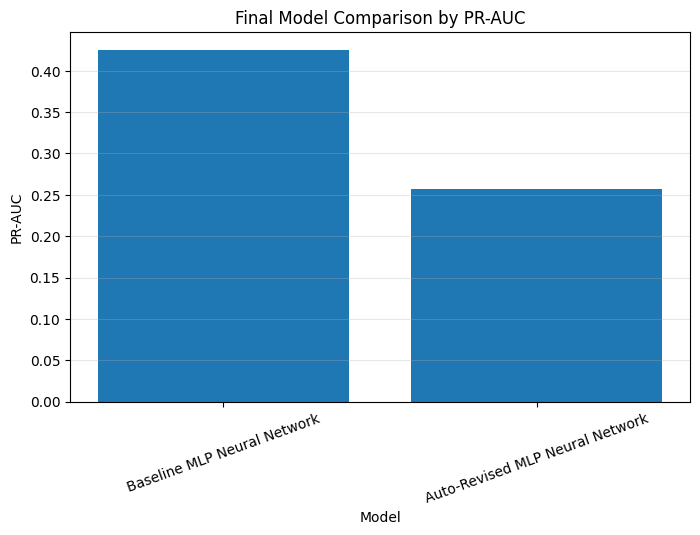

Figure saved: figures/figure_09_final_f1_comparison.png


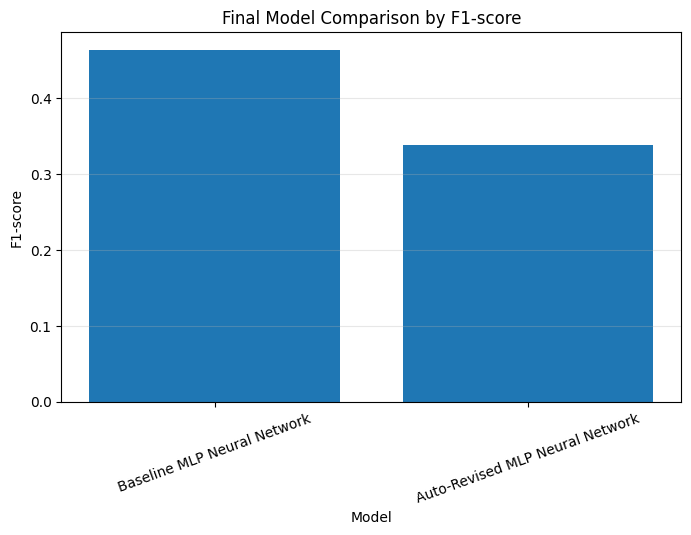

Figure saved: figures/figure_10_roc_curve.png


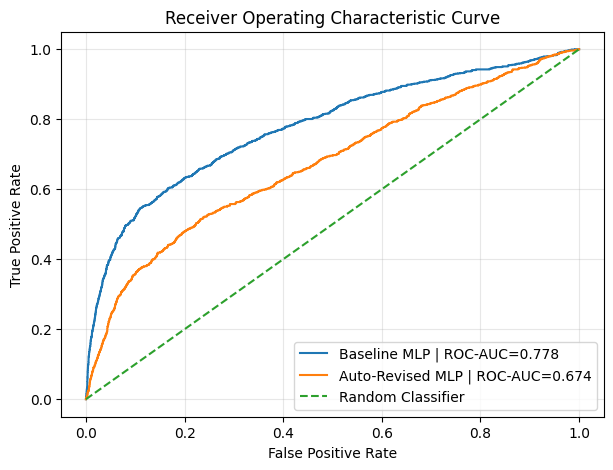

Figure saved: figures/figure_10_precision_recall_curve.png


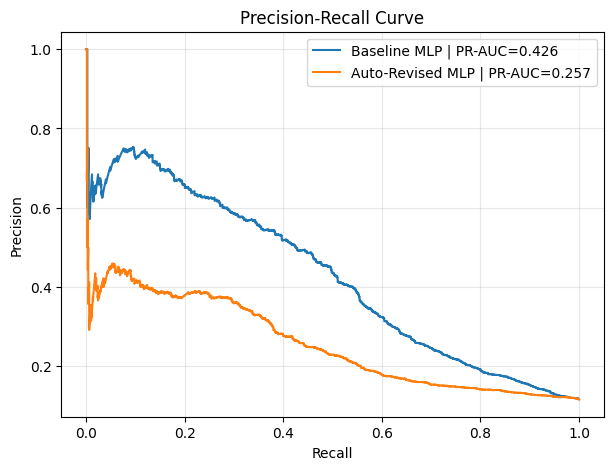

Figure saved: figures/figure_11_calibration_curve.png


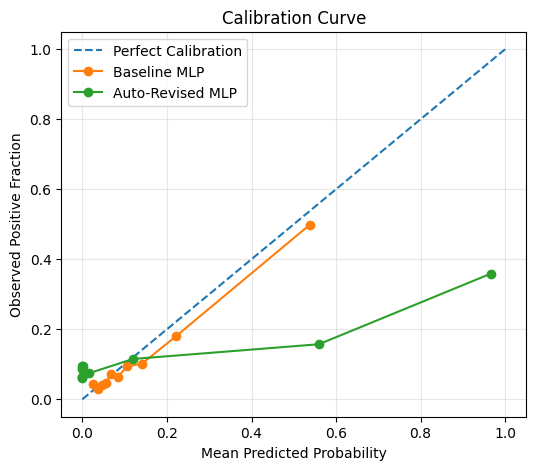

Best model based on PR-AUC: Baseline MLP Neural Network
Best model threshold: 0.28893511573469727


In [9]:
# ============================================================
# Output Title: Final Model Evaluation and Research-Style Reporting
# Deskripsi: Hasil akhir ditampilkan dalam tabel dan grafik standar laporan ilmiah.
# ============================================================

section("Final Model Evaluation and Research-Style Reporting")

results_df = pd.DataFrame([baseline_result, revised_result]).sort_values("pr_auc", ascending=False)
display(results_df)

fig, ax = plt.subplots(figsize=(8.0, 4.8))
ax.bar(results_df["model"], results_df["pr_auc"])
ax.set_title("Final Model Comparison by PR-AUC")
ax.set_xlabel("Model")
ax.set_ylabel("PR-AUC")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.3)
save_or_show(fig, "figure_08_final_pr_auc_comparison.png")

fig, ax = plt.subplots(figsize=(8.0, 4.8))
ax.bar(results_df["model"], results_df["f1_score"])
ax.set_title("Final Model Comparison by F1-score")
ax.set_xlabel("Model")
ax.set_ylabel("F1-score")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.3)
save_or_show(fig, "figure_09_final_f1_comparison.png")

plot_roc_pr_curves(
    {
        "Baseline MLP": baseline_test_proba,
        "Auto-Revised MLP": revised_test_proba
    },
    y_test,
    "figure_10"
)

plot_calibration_curve(
    {
        "Baseline MLP": baseline_test_proba,
        "Auto-Revised MLP": revised_test_proba
    },
    y_test,
    "figure_11_calibration_curve.png"
)

best_model_name = results_df.iloc[0]["model"]
best_threshold = revised_threshold if best_model_name == "Auto-Revised MLP Neural Network" else baseline_threshold
best_estimator = revised_model if best_model_name == "Auto-Revised MLP Neural Network" else baseline_model
best_proba_test = revised_test_proba if best_model_name == "Auto-Revised MLP Neural Network" else baseline_test_proba

print("Best model based on PR-AUC:", best_model_name)
print("Best model threshold:", best_threshold)

## Step 10 — Simple Deployment Test with 7 New Unseen Records

Tahap ini menguji 7 data baru dari hold-out test set. Data ini tidak digunakan untuk training atau resampling, sehingga dapat dipakai sebagai simulasi data baru secara sederhana.


Simple Deployment Test with 7 New Unseen Records


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,campaign,pdays,previous,poutcome,actual_label,predicted_probability_yes,predicted_label,prediction_status
21198,32,technician,single,secondary,no,303,no,no,cellular,14,aug,3,-1,0,NaN,0,0.128291,0,Correct
22128,46,services,married,secondary,no,244,no,no,cellular,21,aug,2,-1,0,NaN,0,0.048659,0,Correct
31281,44,management,single,tertiary,no,483,no,no,cellular,6,mar,2,199,6,success,1,0.791839,1,Correct
39264,58,management,married,primary,no,76,yes,no,telephone,18,may,4,-1,0,NaN,0,0.023170,0,Correct
10830,48,management,married,tertiary,no,2837,no,no,NaN,17,jun,1,-1,0,NaN,0,0.136414,0,Correct
35677,43,blue-collar,married,secondary,no,2,yes,yes,cellular,8,may,5,-1,0,NaN,0,0.037423,0,Correct
43336,31,management,single,tertiary,no,3384,no,no,cellular,22,mar,3,187,3,success,1,0.819246,1,Correct


Simple success rate on 7 unseen hold-out records: 1.0000
Figure saved: figures/figure_12_deployment_test_7_records.png


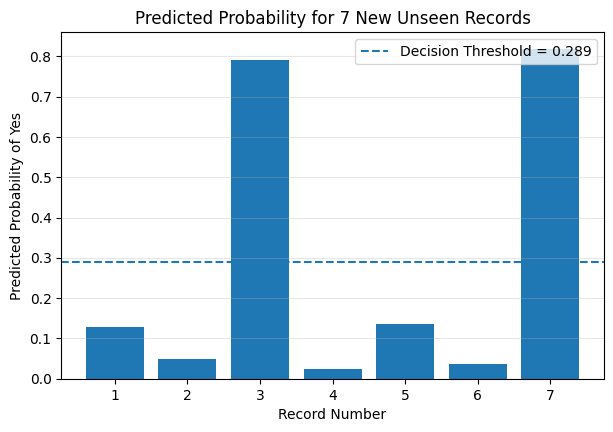

In [10]:
# ============================================================
# Output Title: Simple Deployment Test with 7 New Unseen Records
# Deskripsi: Pengujian sederhana dilakukan pada 7 observasi hold-out yang tidak digunakan saat training.
# ============================================================

section("Simple Deployment Test with 7 New Unseen Records")

new_data_7 = X_test.sample(n=7, random_state=RANDOM_STATE).copy()
actual_7 = y_test.loc[new_data_7.index].copy()

new_data_7_processed = preprocess.transform(new_data_7)
new_data_7_proba = best_estimator.predict_proba(new_data_7_processed)[:, 1]
new_data_7_pred = (new_data_7_proba >= best_threshold).astype(int)

deployment_test_df = new_data_7.copy()
deployment_test_df["actual_label"] = actual_7.values
deployment_test_df["predicted_probability_yes"] = new_data_7_proba
deployment_test_df["predicted_label"] = new_data_7_pred
deployment_test_df["prediction_status"] = np.where(
    deployment_test_df["actual_label"] == deployment_test_df["predicted_label"],
    "Correct",
    "Incorrect"
)

display(deployment_test_df)

simple_success_rate = (deployment_test_df["prediction_status"] == "Correct").mean()
print(f"Simple success rate on 7 unseen hold-out records: {simple_success_rate:.4f}")

fig, ax = plt.subplots(figsize=(7.0, 4.5))
ax.bar(range(1, 8), deployment_test_df["predicted_probability_yes"])
ax.axhline(best_threshold, linestyle="--", label=f"Decision Threshold = {best_threshold:.3f}")
ax.set_title("Predicted Probability for 7 New Unseen Records")
ax.set_xlabel("Record Number")
ax.set_ylabel("Predicted Probability of Yes")
ax.legend()
ax.grid(axis="y", alpha=0.3)
save_or_show(fig, "figure_12_deployment_test_7_records.png")

## Step 11 — Save Production Model with Joblib

Tahap ini membangun pipeline produksi yang memuat preprocessing, oversampling train-only, dan model MLP. Pipeline disimpan dengan `joblib` sehingga aplikasi Streamlit dapat memuat model secara langsung.

In [11]:
# ============================================================
# Output Title: Save Production Model with Joblib
# Deskripsi: Model produksi disimpan sebagai pipeline joblib agar siap digunakan di aplikasi Streamlit.
# ============================================================

section("Save Production Model with Joblib")

import joblib
from imblearn.pipeline import Pipeline as ImbPipeline

production_model = MLPClassifier(
    hidden_layer_sizes=revised_hidden_layers,
    activation="relu",
    solver="adam",
    alpha=revised_alpha,
    batch_size=256,
    learning_rate_init=revised_learning_rate,
    max_iter=250,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    random_state=RANDOM_STATE
)

production_pipeline = ImbPipeline(steps=[
    ("preprocess", preprocess),
    ("sampler", RandomOverSampler(random_state=RANDOM_STATE)),
    ("model", production_model)
])

# Model produksi dilatih pada train_full, bukan test set.
production_pipeline.fit(X_train_full, y_train_full)

production_model_path = MODEL_DIR / "production_bank_marketing_pipeline.joblib"
joblib.dump(production_pipeline, production_model_path)

feature_schema = {
    "features": X.columns.tolist(),
    "numeric_features": numeric_features_all,
    "categorical_features": categorical_features_all,
    "target_mapping": {"no": 0, "yes": 1},
    "use_duration": USE_DURATION,
    "numeric_stats": {
        col: {
            "min": float(X[col].min()),
            "max": float(X[col].max()),
            "median": float(X[col].median())
        }
        for col in numeric_features_all
    },
    "categorical_values": {
        col: sorted([str(value) for value in X[col].dropna().unique().tolist()])
        for col in categorical_features_all
    },
    "decision_threshold": float(best_threshold),
    "best_model_name": str(best_model_name)
}

schema_path = ARTIFACT_DIR / "feature_schema.json"
with open(schema_path, "w", encoding="utf-8") as file:
    json.dump(feature_schema, file, indent=4)

print("Production model saved to:", production_model_path)
print("Feature schema saved to:", schema_path)


Save Production Model with Joblib
Production model saved to: artifacts/models/production_bank_marketing_pipeline.joblib
Feature schema saved to: artifacts/feature_schema.json


## Step 12 — Build Streamlit Application

Tahap ini membuat file `app.py`. Aplikasi memungkinkan prediksi satu nasabah dan prediksi batch melalui file CSV.

In [12]:
# ============================================================
# Output Title: Build Streamlit Application
# Deskripsi: File aplikasi Streamlit dibuat otomatis agar model dapat diuji secara interaktif.
# ============================================================

section("Build Streamlit Application")

streamlit_app_code = r"""
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import streamlit as st

st.set_page_config(
    page_title="Bank Marketing Prediction App",
    page_icon="🏦",
    layout="wide"
)

MODEL_PATH = Path("artifacts/models/production_bank_marketing_pipeline.joblib")
SCHEMA_PATH = Path("artifacts/feature_schema.json")

@st.cache_resource
def load_artifacts():
    if not MODEL_PATH.exists():
        raise FileNotFoundError(f"Model file not found: {MODEL_PATH}")
    if not SCHEMA_PATH.exists():
        raise FileNotFoundError(f"Schema file not found: {SCHEMA_PATH}")
    model = joblib.load(MODEL_PATH)
    with open(SCHEMA_PATH, "r", encoding="utf-8") as file:
        schema = json.load(file)
    return model, schema

st.title("Bank Marketing Term Deposit Prediction App")
st.markdown(
    "This app predicts the probability that a client subscribes to a term deposit. "
    "The model is loaded from a reproducible joblib pipeline."
)

try:
    model, schema = load_artifacts()
except Exception as error:
    st.error(str(error))
    st.stop()

features = schema["features"]
numeric_features = schema["numeric_features"]
categorical_features = schema["categorical_features"]
threshold = float(schema["decision_threshold"])

tab_single, tab_batch, tab_schema = st.tabs(["Single Prediction", "Batch Prediction", "Feature Schema"])

with tab_single:
    st.subheader("Single Client Prediction")
    st.caption("Fill the client profile below. The app will estimate the probability of term deposit subscription.")

    input_data = {}

    left_col, right_col = st.columns(2)

    for index, feature in enumerate(features):
        active_col = left_col if index % 2 == 0 else right_col

        if feature in numeric_features:
            stats = schema["numeric_stats"][feature]
            input_data[feature] = active_col.number_input(
                label=feature,
                min_value=float(stats["min"]),
                max_value=float(stats["max"]),
                value=float(stats["median"])
            )
        elif feature in categorical_features:
            values = schema["categorical_values"][feature]
            input_data[feature] = active_col.selectbox(
                label=feature,
                options=values,
                index=0
            )

    input_df = pd.DataFrame([input_data])

    if st.button("Predict Term Deposit Subscription"):
        probability_yes = float(model.predict_proba(input_df)[:, 1][0])
        predicted_label = int(probability_yes >= threshold)

        st.metric("Predicted Probability of Yes", f"{probability_yes:.4f}")
        st.metric("Decision Threshold", f"{threshold:.4f}")

        if predicted_label == 1:
            st.success("Prediction: YES — the client is predicted to subscribe.")
        else:
            st.warning("Prediction: NO — the client is predicted not to subscribe.")

        st.write("Input Data")
        st.dataframe(input_df, use_container_width=True)

with tab_batch:
    st.subheader("Batch Prediction from CSV")
    st.caption("Upload a CSV file with the same feature columns used by the model.")

    uploaded_file = st.file_uploader("Upload CSV", type=["csv"])

    if uploaded_file is not None:
        batch_df = pd.read_csv(uploaded_file)
        missing_cols = [col for col in features if col not in batch_df.columns]

        if missing_cols:
            st.error(f"Missing required columns: {missing_cols}")
        else:
            batch_input = batch_df[features].copy()
            probabilities = model.predict_proba(batch_input)[:, 1]
            predictions = (probabilities >= threshold).astype(int)

            output_df = batch_input.copy()
            output_df["predicted_probability_yes"] = probabilities
            output_df["predicted_label"] = predictions

            st.write("Prediction Result")
            st.dataframe(output_df, use_container_width=True)

            csv_output = output_df.to_csv(index=False).encode("utf-8")
            st.download_button(
                label="Download Prediction Result",
                data=csv_output,
                file_name="bank_marketing_prediction_result.csv",
                mime="text/csv"
            )

with tab_schema:
    st.subheader("Model Feature Schema")
    st.write("Required features:")
    st.write(features)
    st.write("Numeric features:")
    st.write(numeric_features)
    st.write("Categorical features:")
    st.write(categorical_features)
    st.info("Integrity note: this app should be used only with data that follows the same schema as the training dataset.")
"""

with open("app.py", "w", encoding="utf-8") as file:
    file.write(streamlit_app_code)

print("Streamlit application file created: app.py")
print("The application uses artifacts/models/production_bank_marketing_pipeline.joblib")
print("The application uses artifacts/feature_schema.json")


Build Streamlit Application
Streamlit application file created: app.py
The application uses artifacts/models/production_bank_marketing_pipeline.joblib
The application uses artifacts/feature_schema.json


## Step 13 — Run Streamlit with ngrok

Tahap ini menjalankan Streamlit dan membuka akses publik melalui ngrok. Token ngrok dimasukkan secara aman melalui environment variable, Colab Secrets, atau prompt tersembunyi. Jangan menulis token langsung di notebook yang akan dibagikan.

In [13]:
# ============================================================
# Output Title: Run Streamlit Application with ngrok
# Deskripsi: Aplikasi dijalankan secara interaktif melalui Streamlit dan ngrok.
# ============================================================

section("Run Streamlit Application with ngrok")

from pyngrok import ngrok

def get_ngrok_token():
    token = os.environ.get("NGROK_AUTH_TOKEN", "")

    if not token:
        try:
            from google.colab import userdata
            token = userdata.get("NGROK_AUTH_TOKEN")
        except Exception:
            token = ""

    if not token:
        token = getpass.getpass("Enter your ngrok authtoken: ")

    return token

try:
    ngrok.kill()

    NGROK_AUTH_TOKEN = get_ngrok_token()
    if not NGROK_AUTH_TOKEN:
        raise ValueError("ngrok authtoken is empty. Set NGROK_AUTH_TOKEN or paste it into the hidden prompt.")

    ngrok.set_auth_token(NGROK_AUTH_TOKEN)

    streamlit_process = subprocess.Popen(
        ["streamlit", "run", "app.py", "--server.port", "8501", "--server.address", "0.0.0.0"],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True
    )

    time.sleep(5)

    public_url = ngrok.connect(addr=8501, proto="http")
    print("Streamlit public URL:", public_url)
    print("If the app does not open, re-run this cell after checking the token and model artifact paths.")

except Exception as error:
    print("Deployment error detected:")
    print(error)
    print("\nLogical repair steps:")
    print("1. Ensure app.py exists by running Step 12.")
    print("2. Ensure production joblib model exists by running Step 11.")
    print("3. Ensure NGROK_AUTH_TOKEN is valid and active.")
    print("4. Restart runtime if an old ngrok tunnel is still active.")


Run Streamlit Application with ngrok
Enter your ngrok authtoken: ··········
Streamlit public URL: NgrokTunnel: "https://edginess-reunion-marshland.ngrok-free.dev" -> "http://localhost:8501"
If the app does not open, re-run this cell after checking the token and model artifact paths.


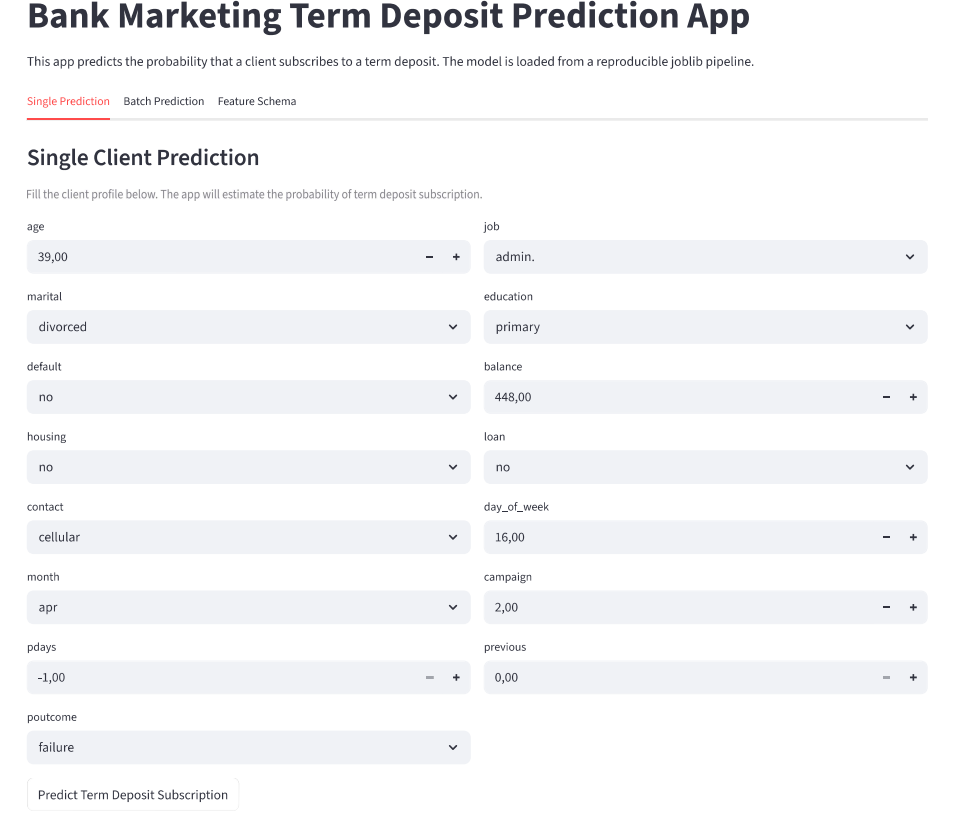

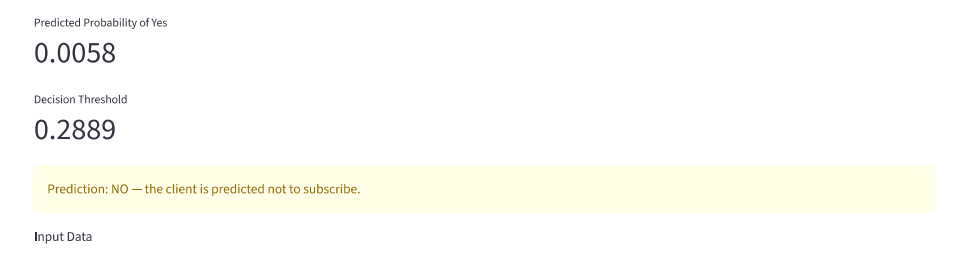

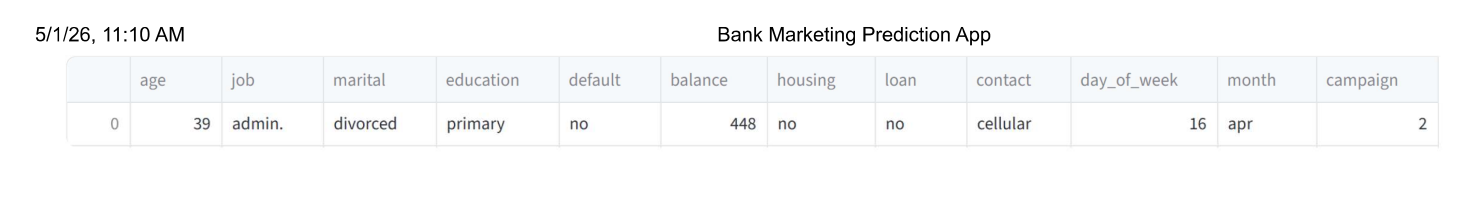

## Step 14 — Save Tables, Figures, and Research Artifacts

Tahap ini menyimpan hasil akhir agar penelitian dapat direplikasi dan diaudit.

In [14]:
# ============================================================
# Output Title: Save Tables, Figures, and Research Artifacts
# Deskripsi: Semua output penting disimpan sebagai artefak penelitian.
# ============================================================

section("Save Tables, Figures, and Research Artifacts")

results_df.to_csv(TABLE_DIR / "final_model_results.csv", index=False)
diagnosis_df.to_csv(TABLE_DIR / "model_diagnosis.csv", index=False)
recommendations_df.to_csv(TABLE_DIR / "logical_revision_recommendations.csv", index=False)
revision_config.to_csv(TABLE_DIR / "automatic_revision_configuration.csv", index=False)
deployment_test_df.to_csv(TABLE_DIR / "simple_deployment_test_7_records.csv", index=False)

X_raw.to_csv(DATA_DIR / "X_raw.csv", index=False)
pd.DataFrame({"target_encoded": y}).to_csv(DATA_DIR / "target_encoded.csv", index=False)

experiment_config = {
    "research_title": "Bank Marketing Neural Network Research Pipeline and Streamlit Deployment",
    "random_state": RANDOM_STATE,
    "use_duration": USE_DURATION,
    "leakage_control": "duration removed in the realistic pre-call prediction scenario",
    "primary_metric": "PR-AUC",
    "best_model_name": str(best_model_name),
    "best_threshold": float(best_threshold),
    "revision_strategy": str(revision_strategy),
    "model_artifact": str(production_model_path),
    "streamlit_app": "app.py",
    "integrity_statement": "All research metrics must be taken from executed notebook outputs."
}

with open(ARTIFACT_DIR / "experiment_config.json", "w", encoding="utf-8") as file:
    json.dump(experiment_config, file, indent=4)

!pip freeze > artifacts/requirements_freeze.txt

print("All research and deployment artifacts have been saved.")
print("Final result table:", TABLE_DIR / "final_model_results.csv")
print("Deployment test table:", TABLE_DIR / "simple_deployment_test_7_records.csv")
print("Production model:", production_model_path)
print("Streamlit app file: app.py")


Save Tables, Figures, and Research Artifacts
All research and deployment artifacts have been saved.
Final result table: artifacts/tables/final_model_results.csv
Deployment test table: artifacts/tables/simple_deployment_test_7_records.csv
Production model: artifacts/models/production_bank_marketing_pipeline.joblib
Streamlit app file: app.py


## Step 15 — Scientific Discussion Template

Gunakan template ini setelah notebook dijalankan. Jangan mengisi angka secara manual sebelum melihat output.

**Suggested scientific discussion in English:**

> The final model was selected based on PR-AUC because the positive class is relatively underrepresented. The evaluation was performed on an independent test set that was not used for training, validation, threshold tuning, or resampling. The automatic revision procedure was considered methodologically valid because it applied oversampling only on the training data and preserved the original validation and test distributions. If the revised model improved PR-AUC, F1-score, or recall compared with the baseline model, the improvement can be interpreted as evidence that imbalance-aware revision improved generalization. If the revised model did not outperform the baseline, the valid conclusion is that the proposed revision did not improve generalization under the current experimental setting.

**Pembahasan logis dalam Bahasa Indonesia:**

Model akhir harus dibahas berdasarkan hasil aktual pada tabel `final_model_results.csv`. Apabila model revisi memiliki PR-AUC lebih tinggi, maka revisi berbasis diagnosis dapat dinyatakan berhasil secara empiris. Namun, apabila model baseline lebih tinggi, maka keputusan ilmiah yang benar adalah mempertahankan baseline sebagai model terbaik. Dengan demikian, integritas pembahasan tetap terjaga karena kesimpulan mengikuti data, bukan ekspektasi peneliti.